In [1]:
from utils.cnn_utils.cnn_preprocessing_utils import CNNPreprocessor

In [3]:
cnn_preprocessor = CNNPreprocessor(sensors_path="../../../../data/ml/features_machine_and_movement_complete.csv", target_path="../../../../data/ml/targets_movement_complete.csv")

In [4]:
sensors_df, target_df = cnn_preprocessor.read_data()
sensors_df = cnn_preprocessor.feature_selection()
cnn_preprocessor.normalize_angle()

,Experiment_ID,Angle[degree]ORDistance[mm],Secondary-axis [mm],Main-axis [mm],Out-of-roundness [-],Collapse [mm]
0,2,0.000000,0.317461,0.337050,0.626034,0.344543
1,2,0.022017,0.319825,0.363018,0.600159,0.372211
2,2,0.044033,0.319035,0.401244,0.560835,0.412939
3,2,0.066050,0.317768,0.438220,0.522651,0.452336
4,2,0.088067,0.320230,0.465094,0.495879,0.480970
...,...,...,...,...,...,...
14558,318,0.902686,0.641596,0.373375,0.680266,0.314326
14559,318,0.924703,0.640550,0.372634,0.680719,0.313536
14560,318,0.946720,0.640334,0.374073,0.679194,0.315070
14561,318,0.968736,0.641037,0.377992,0.675413,0.319245


In [60]:
sensor_data = sensors_df[sensors_df["Experiment_ID"]==2].iloc[:,1:]
sensor_data

,MACHINE_BEND-DIE_LATERAL_Max_Torque_[%],MACHINE_BEND-DIE_ROTATING_Max_Torque_[%],MACHINE_BEND-DIE_VERTICAL_Max_Torque_[%],MACHINE_CLAMP-DIE_LATERAL_Max_Torque_[%],MACHINE_COLLET_AXIAL_Max_Torque_[%],MACHINE_COLLET_ROTATING_Max_Torque_[%],MACHINE_MANDREL_AXIAL_Max_Torque_[%],MACHINE_PRESSURE-DIE_LATERAL_Max_Torque_[%],MACHINE_PRESSURE-DIE_LEFT_AXIAL_Max_Torque_[%],BEND-DIE_LATERAL_Movement_[mm],BEND-DIE_ROTATING_Angle_[°],CLAMP-DIE_LATERAL_Movement_[mm],COLLET_AXIAL_Movement_[mm],MANDREL_AXIAL_Movement_[mm],PRESSURE-DIE_AXIAL_Movement_[mm],PRESSURE-DIE_LATERAL_Movement_[mm]
Time_[s],,,,,,,,,,,,,,,,
0.00,0.135068,0.817045,0.293651,0.436154,0.397692,0.107143,0.985937,0.757580,0.59375,0.999967,1.000000,0.570124,0.000005,0.900879,0.000373,0.999849
0.05,0.135068,0.817045,0.285714,0.436154,0.397822,0.107143,0.985937,0.750271,0.59375,0.999967,1.000000,0.570124,0.000004,0.900879,0.000373,0.999842
0.10,0.135068,0.817045,0.293651,0.436154,0.398065,0.107143,0.984375,0.698300,0.59375,0.999967,1.000000,0.570124,0.000004,0.900879,0.000373,0.999540
0.15,0.136307,0.817045,0.293651,0.436154,0.397887,0.107143,0.985937,0.585460,0.62500,0.999967,1.000000,0.570124,0.000005,0.900879,0.000373,0.998401
0.20,0.135068,0.817045,0.285714,0.436154,0.397741,0.107143,0.984375,0.476972,0.65625,0.999967,1.000000,0.570124,0.000002,0.900879,0.000373,0.997003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40.05,0.656753,0.309956,0.992064,0.742917,0.226657,0.071429,0.925000,0.383626,0.53125,0.999967,0.000168,0.999139,0.271088,0.003316,0.000377,0.000328
40.10,0.656753,0.313056,0.992064,0.742728,0.225943,0.035714,0.923438,0.383889,0.53125,0.999967,0.000109,0.999138,0.271101,0.002068,0.000373,0.000328
40.15,0.656753,0.311989,0.992064,0.742917,0.225439,0.071429,0.925000,0.383763,0.50000,0.999967,0.000062,0.999138,0.271113,0.001094,0.000373,0.000328


/home/arman/Documents/univrsity/Master/Master these 2025/tube-geometry-prediction/tube-venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/arman/Documents/univrsity/Master/Master these 2025/tube-geometry-prediction/tube-venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/arman/Documents/univrsity/Master/Master these 2025/tube-geometry-prediction/tube-venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for fo

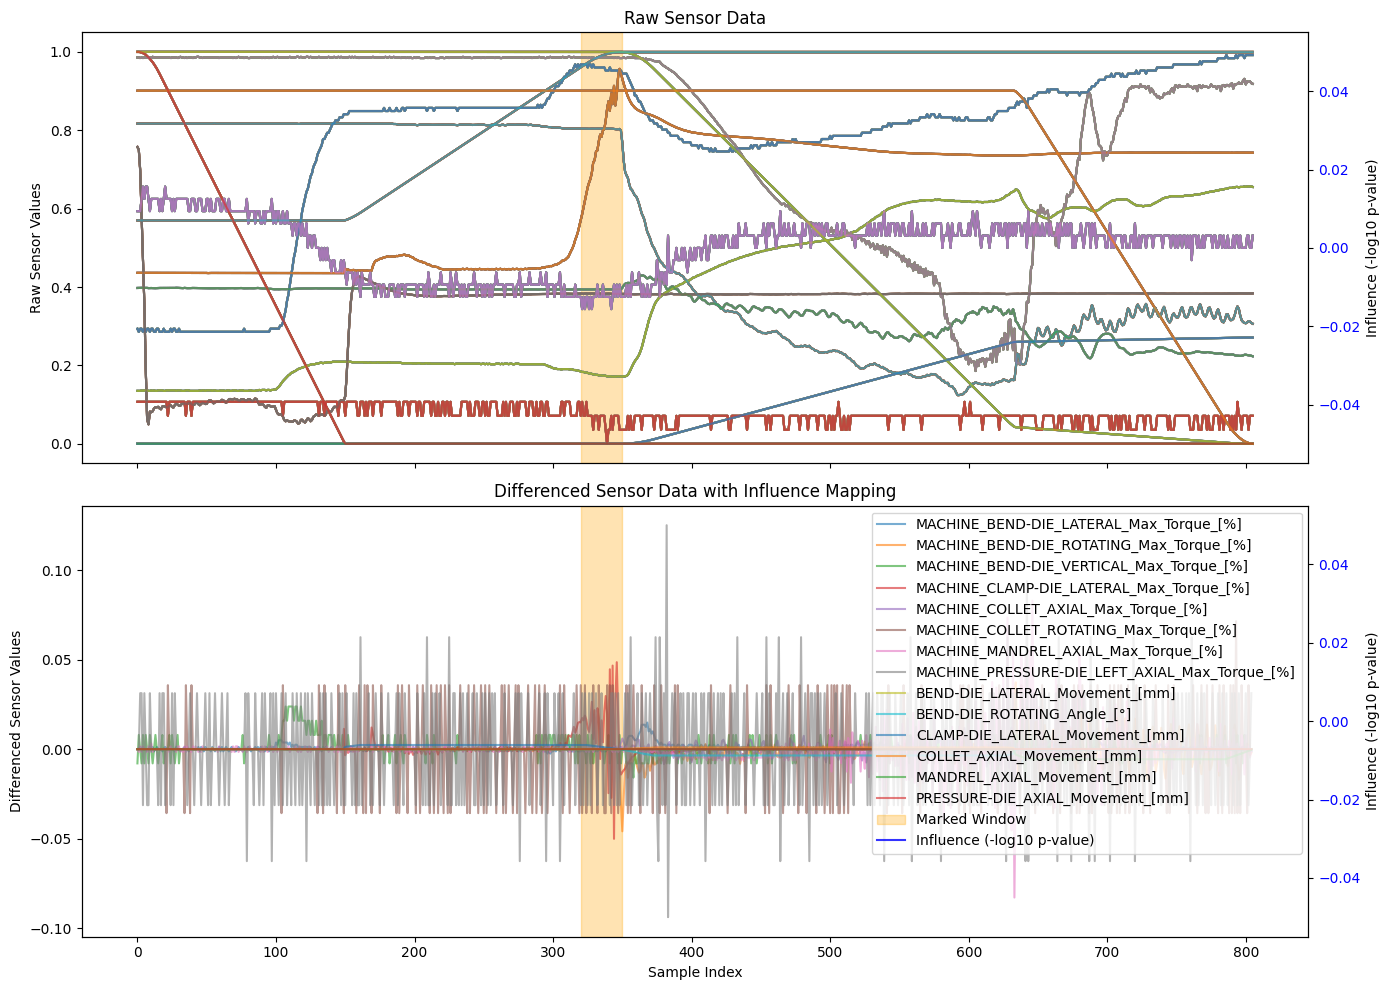

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR

# -------------------------
# 1. Prepare data
# -------------------------
df = sensor_data.copy()
selected_columns = ['MACHINE_BEND-DIE_LATERAL_Max_Torque_[%]',
       'MACHINE_BEND-DIE_ROTATING_Max_Torque_[%]',
       'MACHINE_BEND-DIE_VERTICAL_Max_Torque_[%]',
       'MACHINE_CLAMP-DIE_LATERAL_Max_Torque_[%]',
       'MACHINE_COLLET_AXIAL_Max_Torque_[%]',
       'MACHINE_COLLET_ROTATING_Max_Torque_[%]',
       'MACHINE_MANDREL_AXIAL_Max_Torque_[%]',
       'BEND-DIE_LATERAL_Movement_[mm]', 'BEND-DIE_ROTATING_Angle_[°]',
       'CLAMP-DIE_LATERAL_Movement_[mm]', 'COLLET_AXIAL_Movement_[mm]',
       'MANDREL_AXIAL_Movement_[mm]', 'PRESSURE-DIE_AXIAL_Movement_[mm]']

df_subset = df[selected_columns]
df_diff = df_subset.diff().dropna()
x = np.arange(len(df_diff))

# -------------------------
# 2. Marked window
# -------------------------
effect_start, effect_end = 320, 350
target_col =  ['MACHINE_BEND-DIE_VERTICAL_Max_Torque_[%]', 'BEND-DIE_ROTATING_Angle_[°]']
target_window = df_diff.iloc[effect_start:effect_end]

# -------------------------
# 3. Candidate windows (Granger)
# -------------------------
window_size = 50
step = 5
candidate_starts = range(0, effect_start - window_size + 1, step)
influence_scores = []

for start in candidate_starts:
    candidate_window = df_diff.iloc[start:start + window_size]
    combined = pd.concat([candidate_window, target_window])
    try:
        model = VAR(combined)
        maxlags = min(3, (len(combined)-1)//len(selected_columns))
        results = model.fit(maxlags=maxlags)
        gc_test = results.test_causality(
            target_col,
            [col for col in selected_columns if col != target_col],
            kind='f'
        )
        influence_scores.append(-np.log10(gc_test.pvalue))
    except:
        influence_scores.append(np.nan)

# -------------------------
# 4. Map influence scores to all indices of candidate windows
# -------------------------
influence_mapped = np.zeros(len(df_diff)) * np.nan  # initialize
for score, start in zip(influence_scores, candidate_starts):
    influence_mapped[start:start+window_size] = score  # fill each window with same score

# -------------------------
# 5. Subplots: raw + differenced with influence
# -------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14,10), sharex=True)

# --- Panel 1: raw data ---
for col in df_subset.columns:
    ax1.plot(np.arange(len(sensor_data)), sensor_data.values, label=sensor_data.columns, alpha=0.6)
ax1.axvspan(effect_start, effect_end, color='orange', alpha=0.3, label='Marked Window')
ax_influence = ax1.twinx()
ax_influence.plot(x, influence_mapped, color='blue', alpha=0.8, label='Influence (-log10 p-value)')
ax_influence.set_ylabel("Influence (-log10 p-value)")
ax_influence.tick_params(axis='y', labelcolor='blue')
ax1.set_ylabel("Raw Sensor Values")
ax1.set_title("Raw Sensor Data")

# --- Panel 2: differenced + influence ---
for col in df_diff.columns:
    ax2.plot(x, df_diff[col], label=col, alpha=0.6)
ax2.axvspan(effect_start, effect_end, color='orange', alpha=0.3, label='Marked Window')

ax_influence = ax2.twinx()
ax_influence.plot(x, influence_mapped, color='blue', alpha=0.8, label='Influence (-log10 p-value)')
ax_influence.set_ylabel("Influence (-log10 p-value)")
ax_influence.tick_params(axis='y', labelcolor='blue')

ax2.set_xlabel("Sample Index")
ax2.set_ylabel("Differenced Sensor Values")
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax_influence.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax2.set_title("Differenced Sensor Data with Influence Mapping")

plt.tight_layout()
plt.show()



In [ ]:
from sklearn.feature_selection import mutual_info_regression

X = []
y = target_window[target_col].values

for start in candidate_starts:
    candidate = df.iloc[start:start+window_size][target_col].values
    # flatten to 1D
    X.append(candidate[:len(y)])
X = np.array(X)

mi_scores = mutual_info_regression(X, y)

plt.figure(figsize=(10,4))
plt.plot(candidate_starts, mi_scores, marker='o', color='purple')
plt.axvspan(effect_start, effect_end, color='orange', alpha=0.3)
plt.xlabel("Candidate Window Start Index")
plt.ylabel("Mutual Information")
plt.title("Sliding Window Mutual Information")
plt.show()


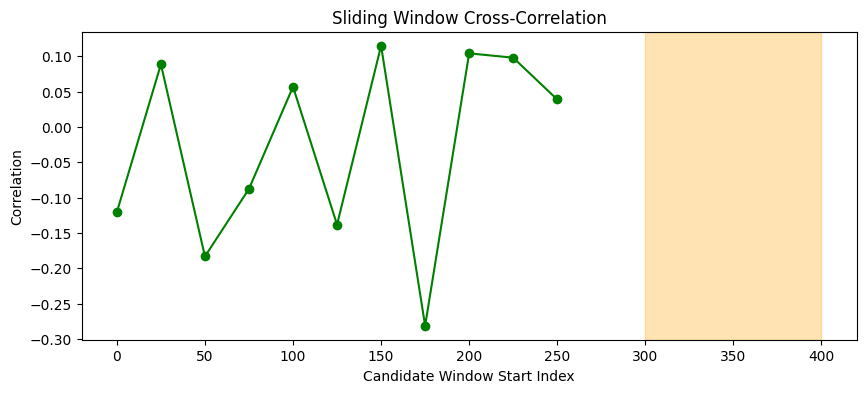

In [25]:
import numpy as np
import matplotlib.pyplot as plt

target_series = target_window[target_col].values
correlations = []

for start in candidate_starts:
    candidate = df.iloc[start:start+window_size][target_col].values
    # Match length
    min_len = min(len(candidate), len(target_series))
    corr = np.corrcoef(candidate[:min_len], target_series[:min_len])[0,1]
    correlations.append(corr)

plt.figure(figsize=(10,4))
plt.plot(candidate_starts, correlations, marker='o', color='green')
plt.axvspan(effect_start, effect_end, color='orange', alpha=0.3)
plt.xlabel("Candidate Window Start Index")
plt.ylabel("Correlation")
plt.title("Sliding Window Cross-Correlation")
plt.show()


In [26]:
from utils.cnn_utils.model import MultiOutputCNN
from utils.cnn_utils.cnn_feature_importance import full_pipeline, get_experiment_analysis, plot_temporal_importance_with_real_names

In [27]:
# Initialize and train model
model = MultiOutputCNN(input_size=X.shape[-1], seq_len=X.shape[1], output_size=Y.shape[-1], num_angles=Y.shape[-2])

Training CNN Model...


Epoch 1/100 | Train Loss: 0.2351 | Test Loss: 0.1475


Epoch 2/100 | Train Loss: 0.1142 | Test Loss: 0.0705


Epoch 3/100 | Train Loss: 0.0625 | Test Loss: 0.0361


Epoch 4/100 | Train Loss: 0.0425 | Test Loss: 0.0223


...

Epoch 96/100 | Train Loss: 0.0088 | Test Loss: 0.0036


Epoch 97/100 | Train Loss: 0.0089 | Test Loss: 0.0036


Epoch 98/100 | Train Loss: 0.0085 | Test Loss: 0.0037


Epoch 99/100 | Train Loss: 0.0088 | Test Loss: 0.0034


Epoch 100/100 | Train Loss: 0.0088 | Test Loss: 0.0037
Model saved to: ../../../../models/cnn/cnn.joblib


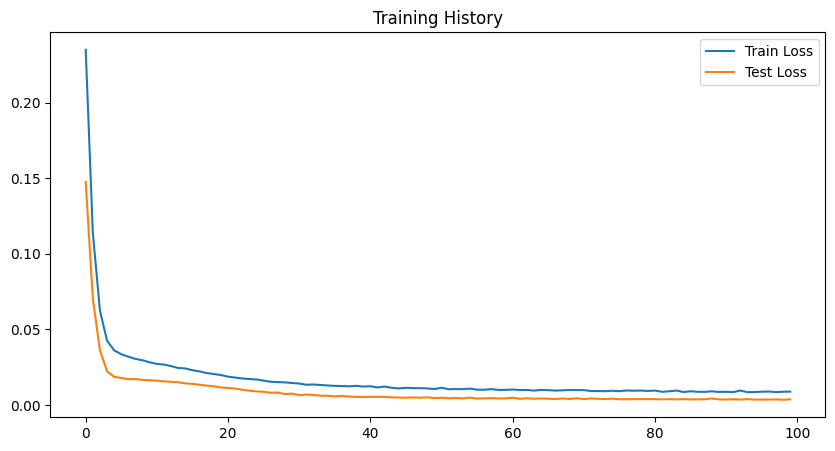

Visualizing Feature Importance...


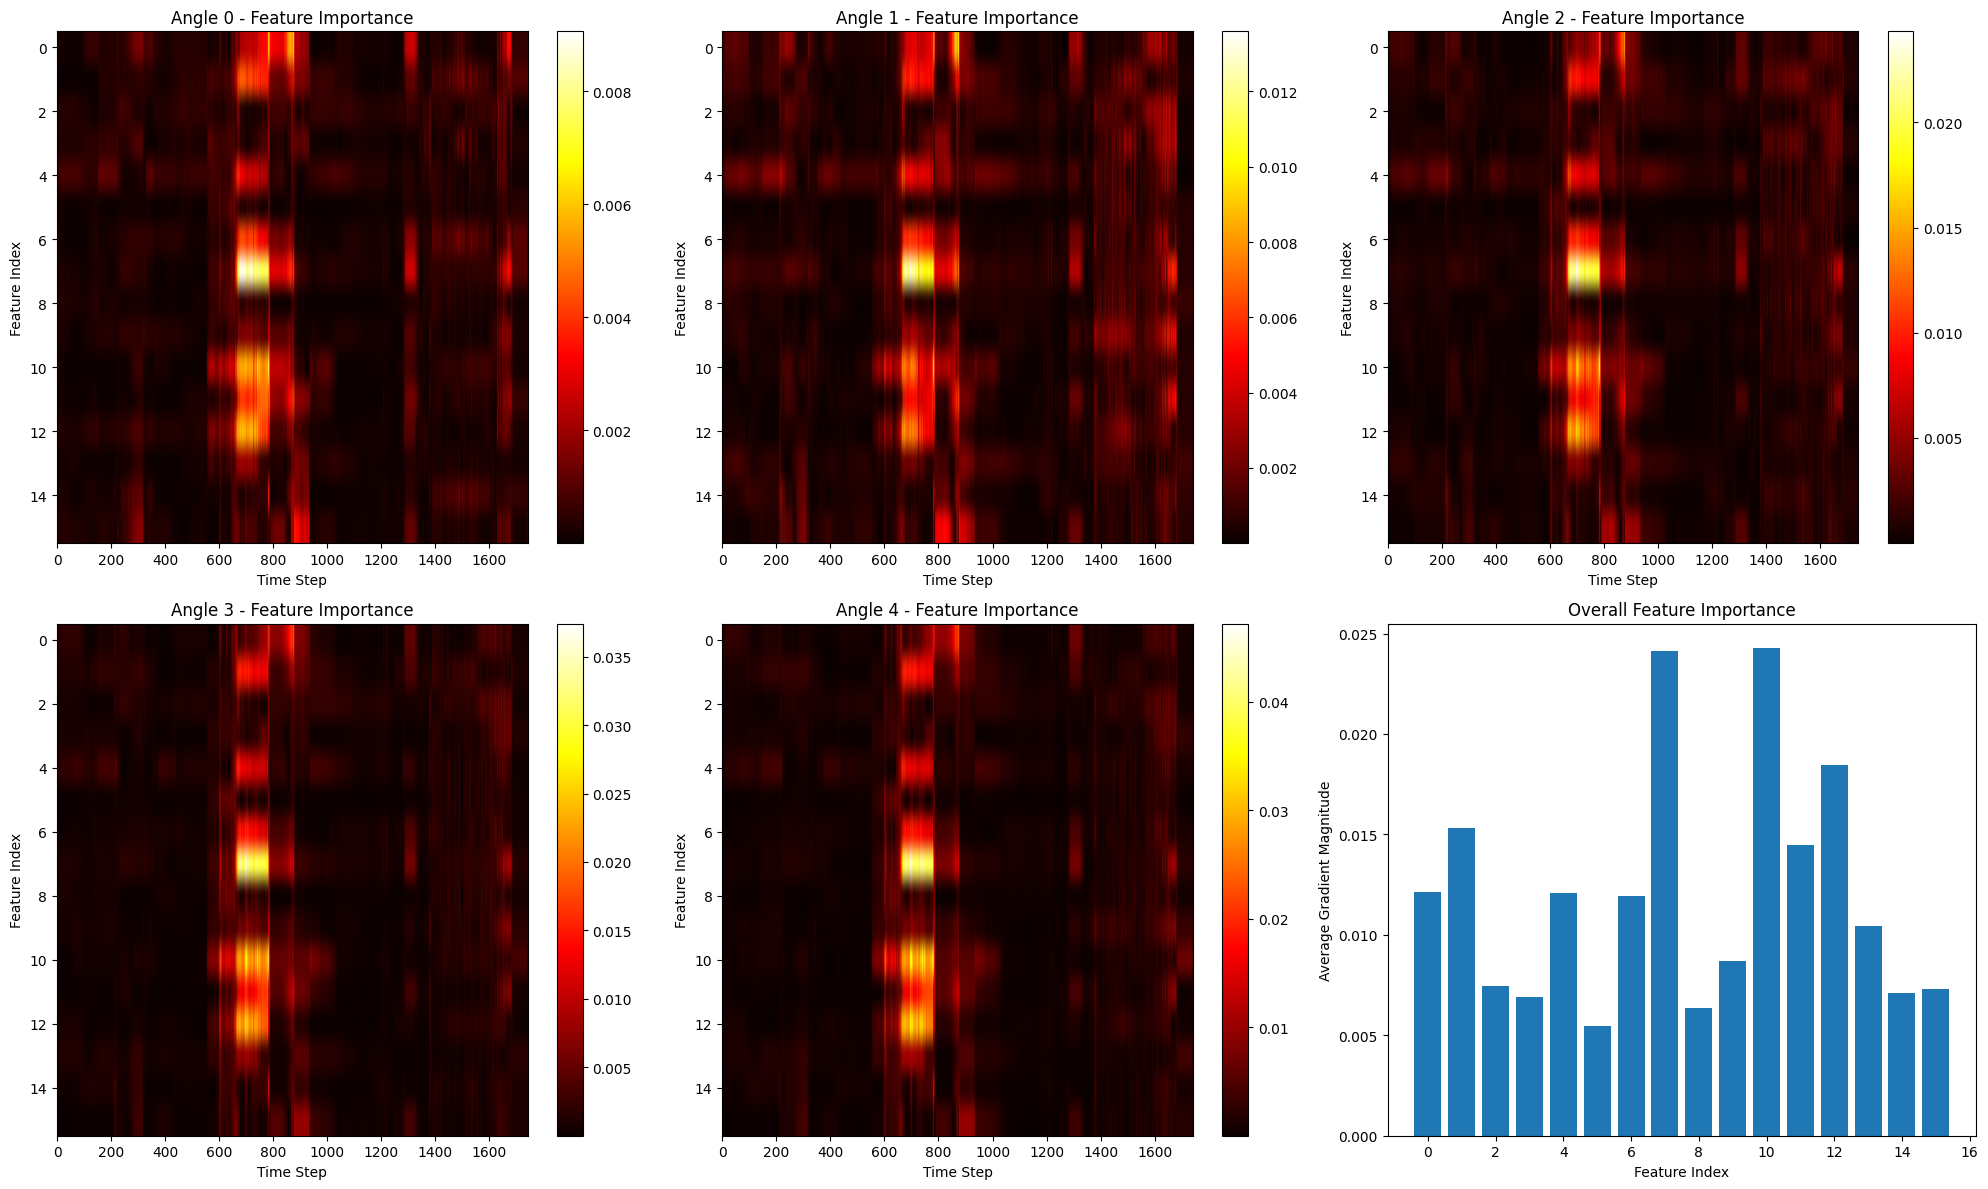

Computing Permutation Importance...


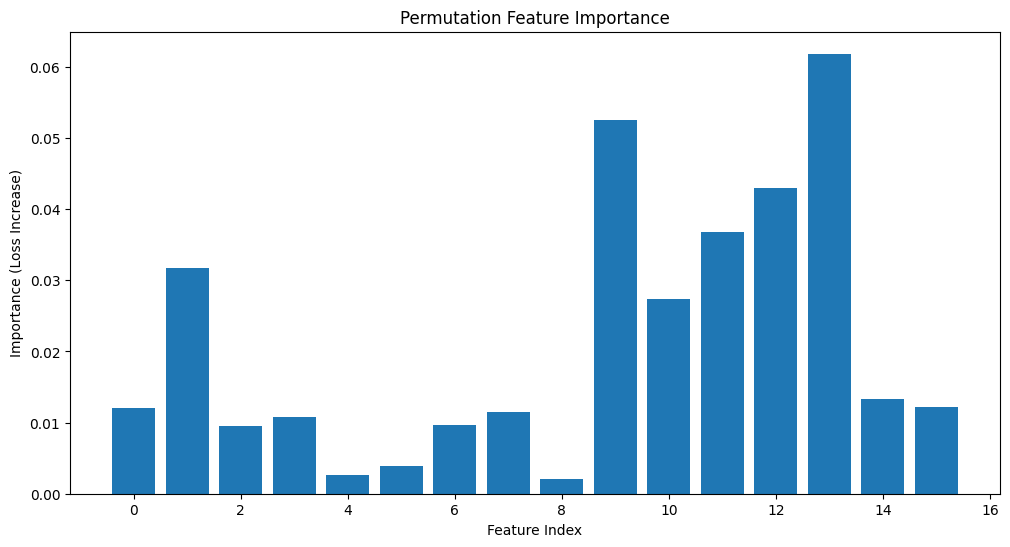

In [28]:
model, importance_maps, perm_importance = full_pipeline(X, Y, model, model_path="../../../../models/cnn/cnn.joblib", num_epochs=100, lr=0.0001)

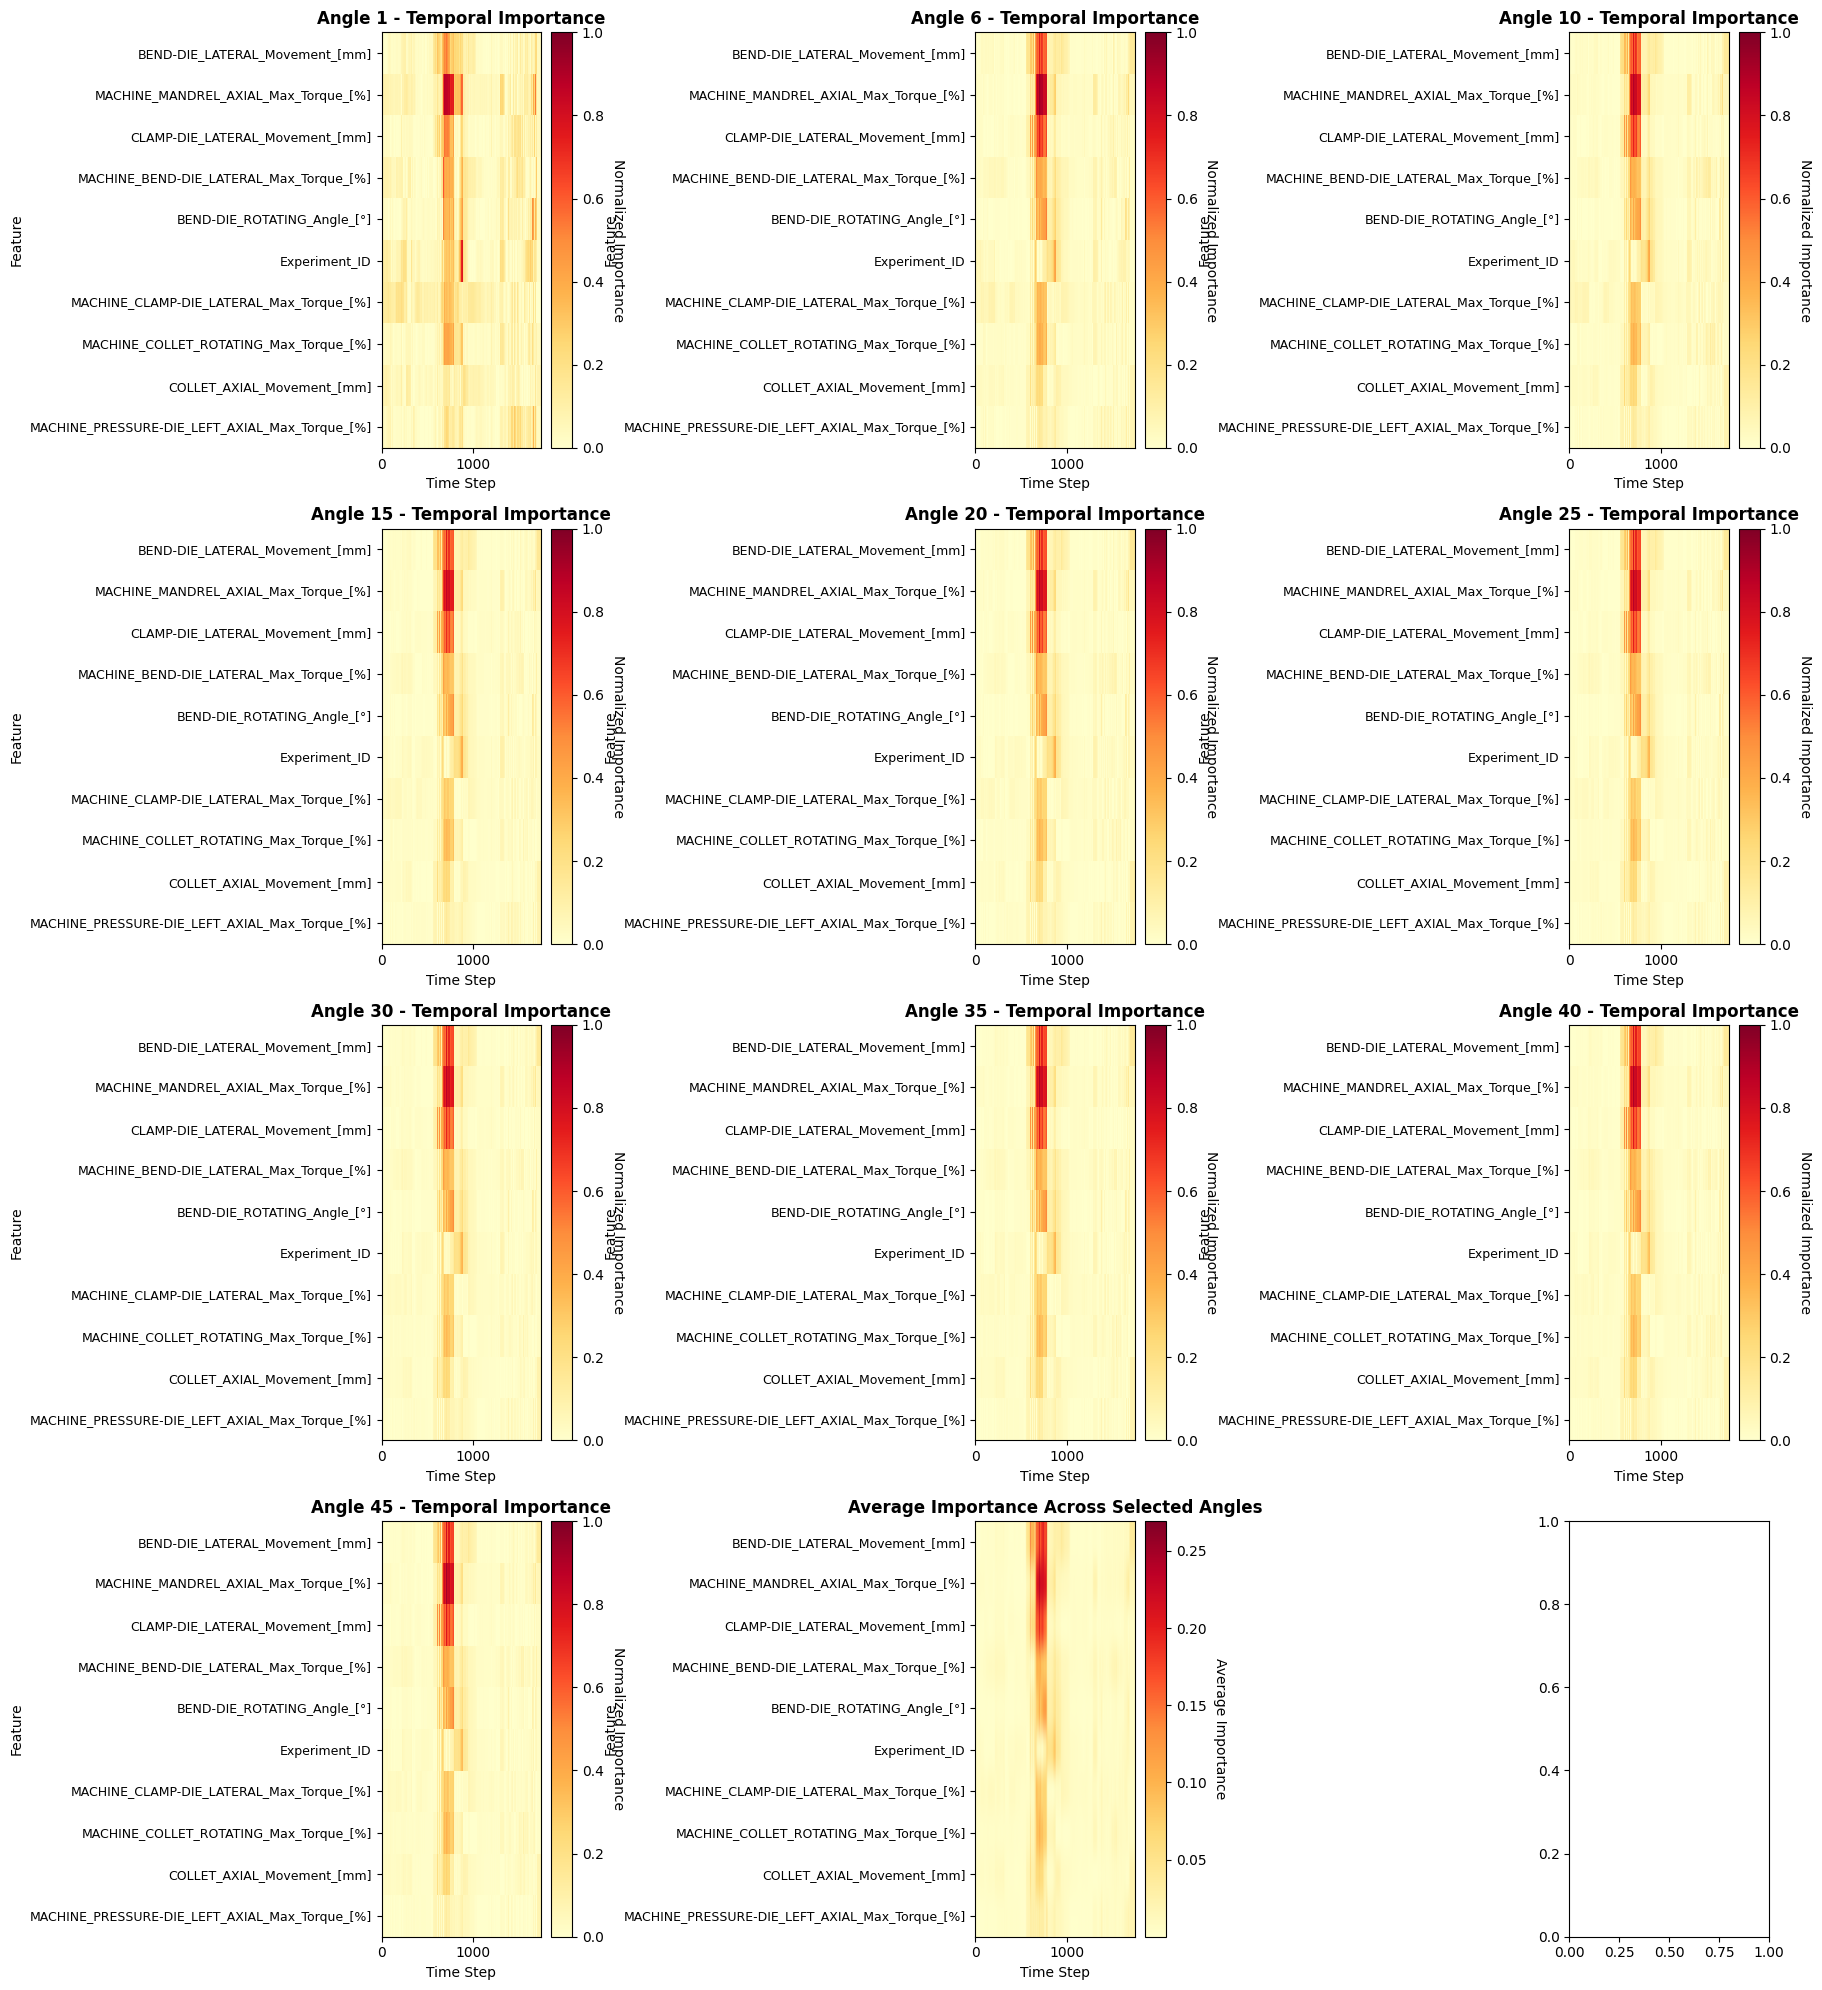

['BEND-DIE_LATERAL_Movement_[mm]',
 'MACHINE_MANDREL_AXIAL_Max_Torque_[%]',
 'CLAMP-DIE_LATERAL_Movement_[mm]',
 'MACHINE_BEND-DIE_LATERAL_Max_Torque_[%]',
 'BEND-DIE_ROTATING_Angle_[°]',
 'Experiment_ID',
 'MACHINE_CLAMP-DIE_LATERAL_Max_Torque_[%]',
 'MACHINE_COLLET_ROTATING_Max_Torque_[%]',
 'COLLET_AXIAL_Movement_[mm]',
 'MACHINE_PRESSURE-DIE_LEFT_AXIAL_Max_Torque_[%]']

In [29]:
plot_temporal_importance_with_real_names(importance_maps, sensors_df, selected_angles=[1,6,10,15,20,25,30,35,40, 45])

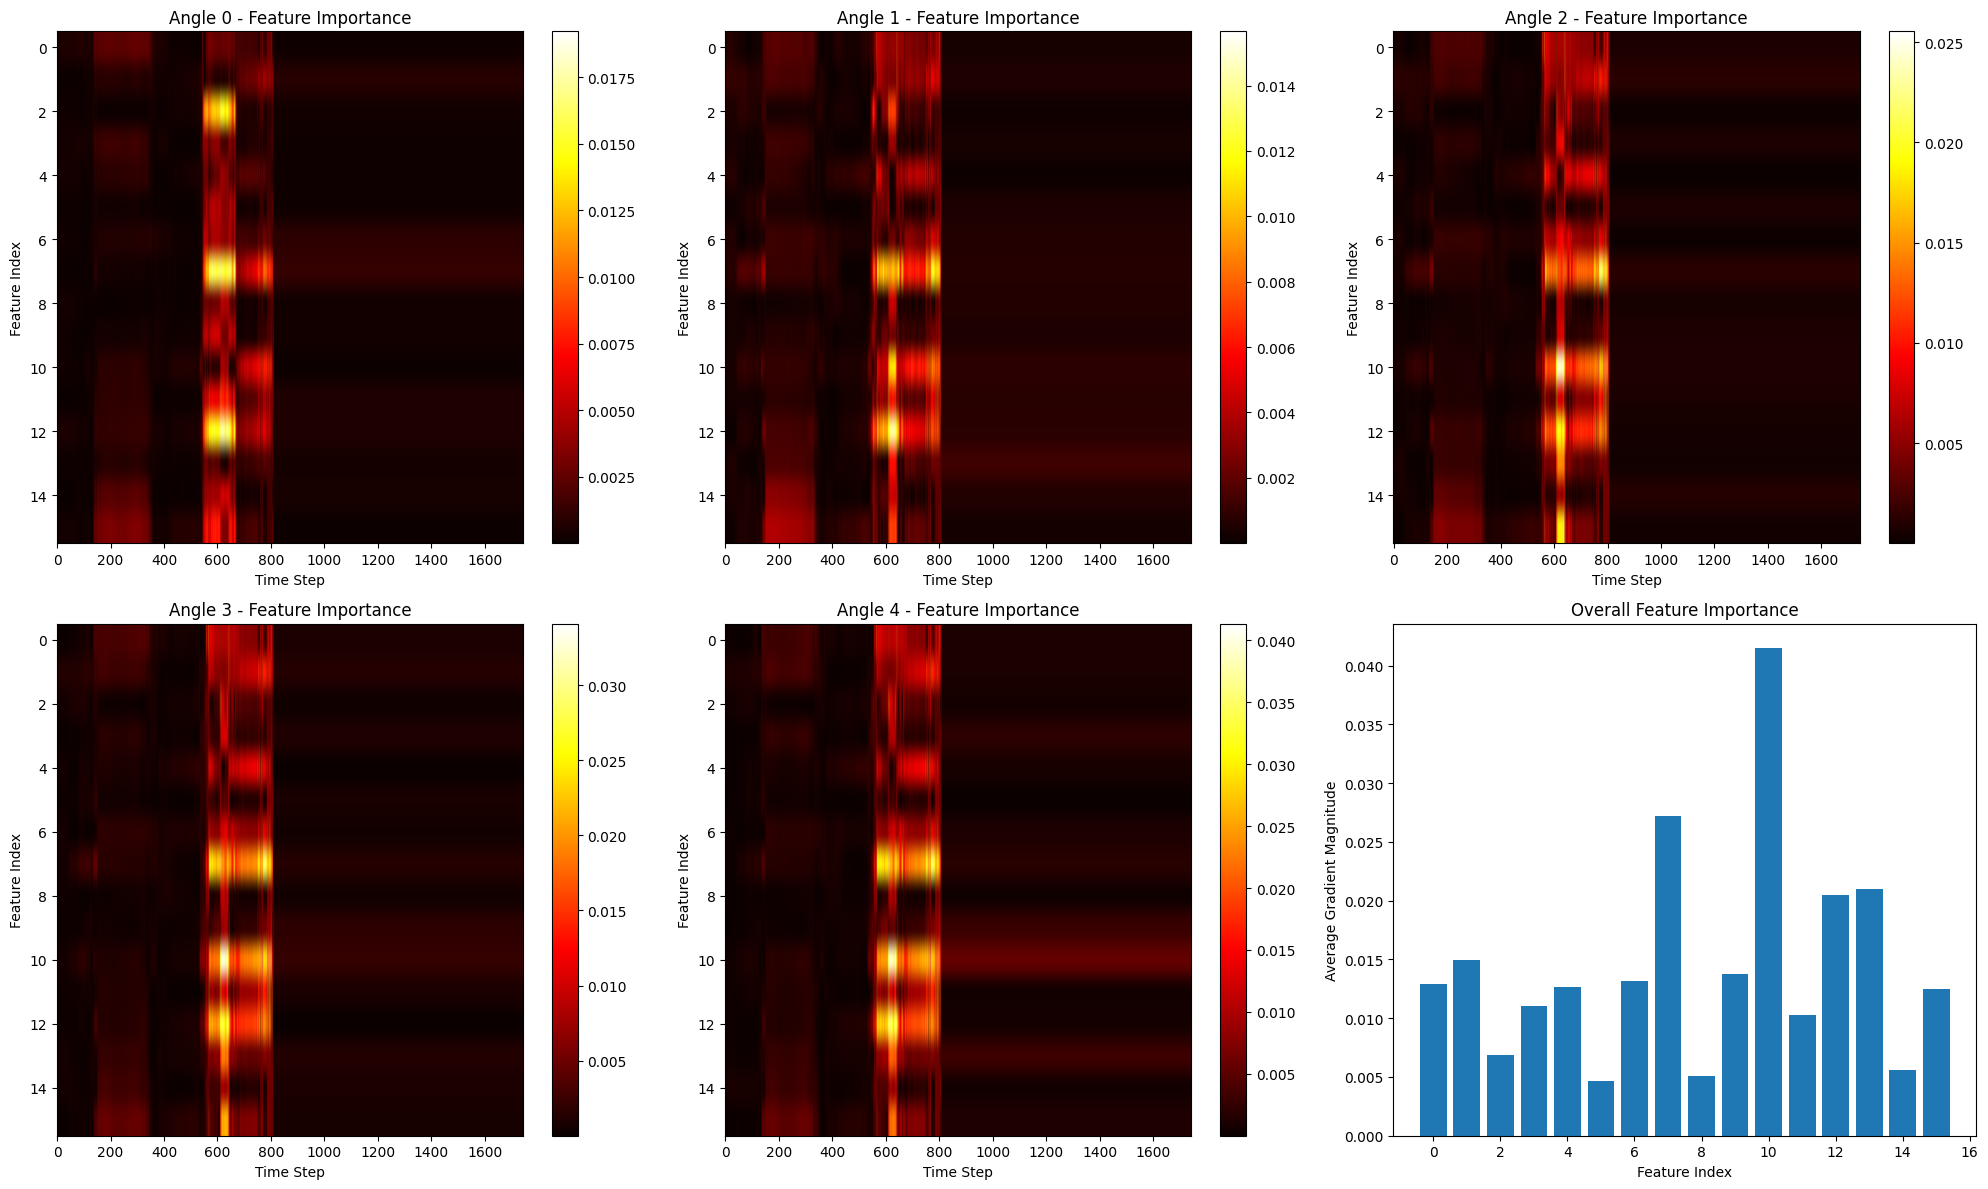

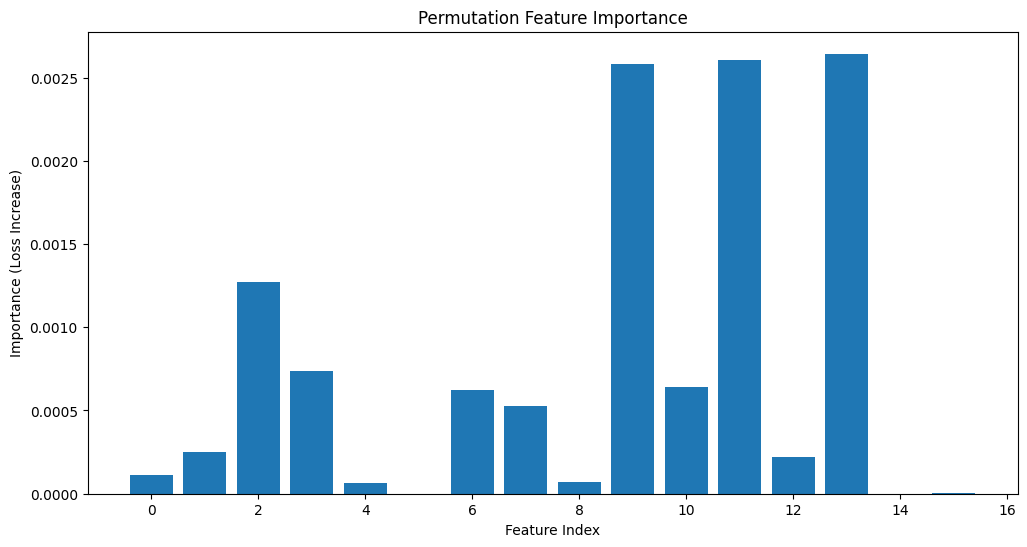

In [31]:
# After training your model
target_id = 2
experiment_ids=[2]
preds, temp_importance, perm_importance = get_experiment_analysis(
    model, X, Y, experiment_ids, target_experiment_id=target_id
)

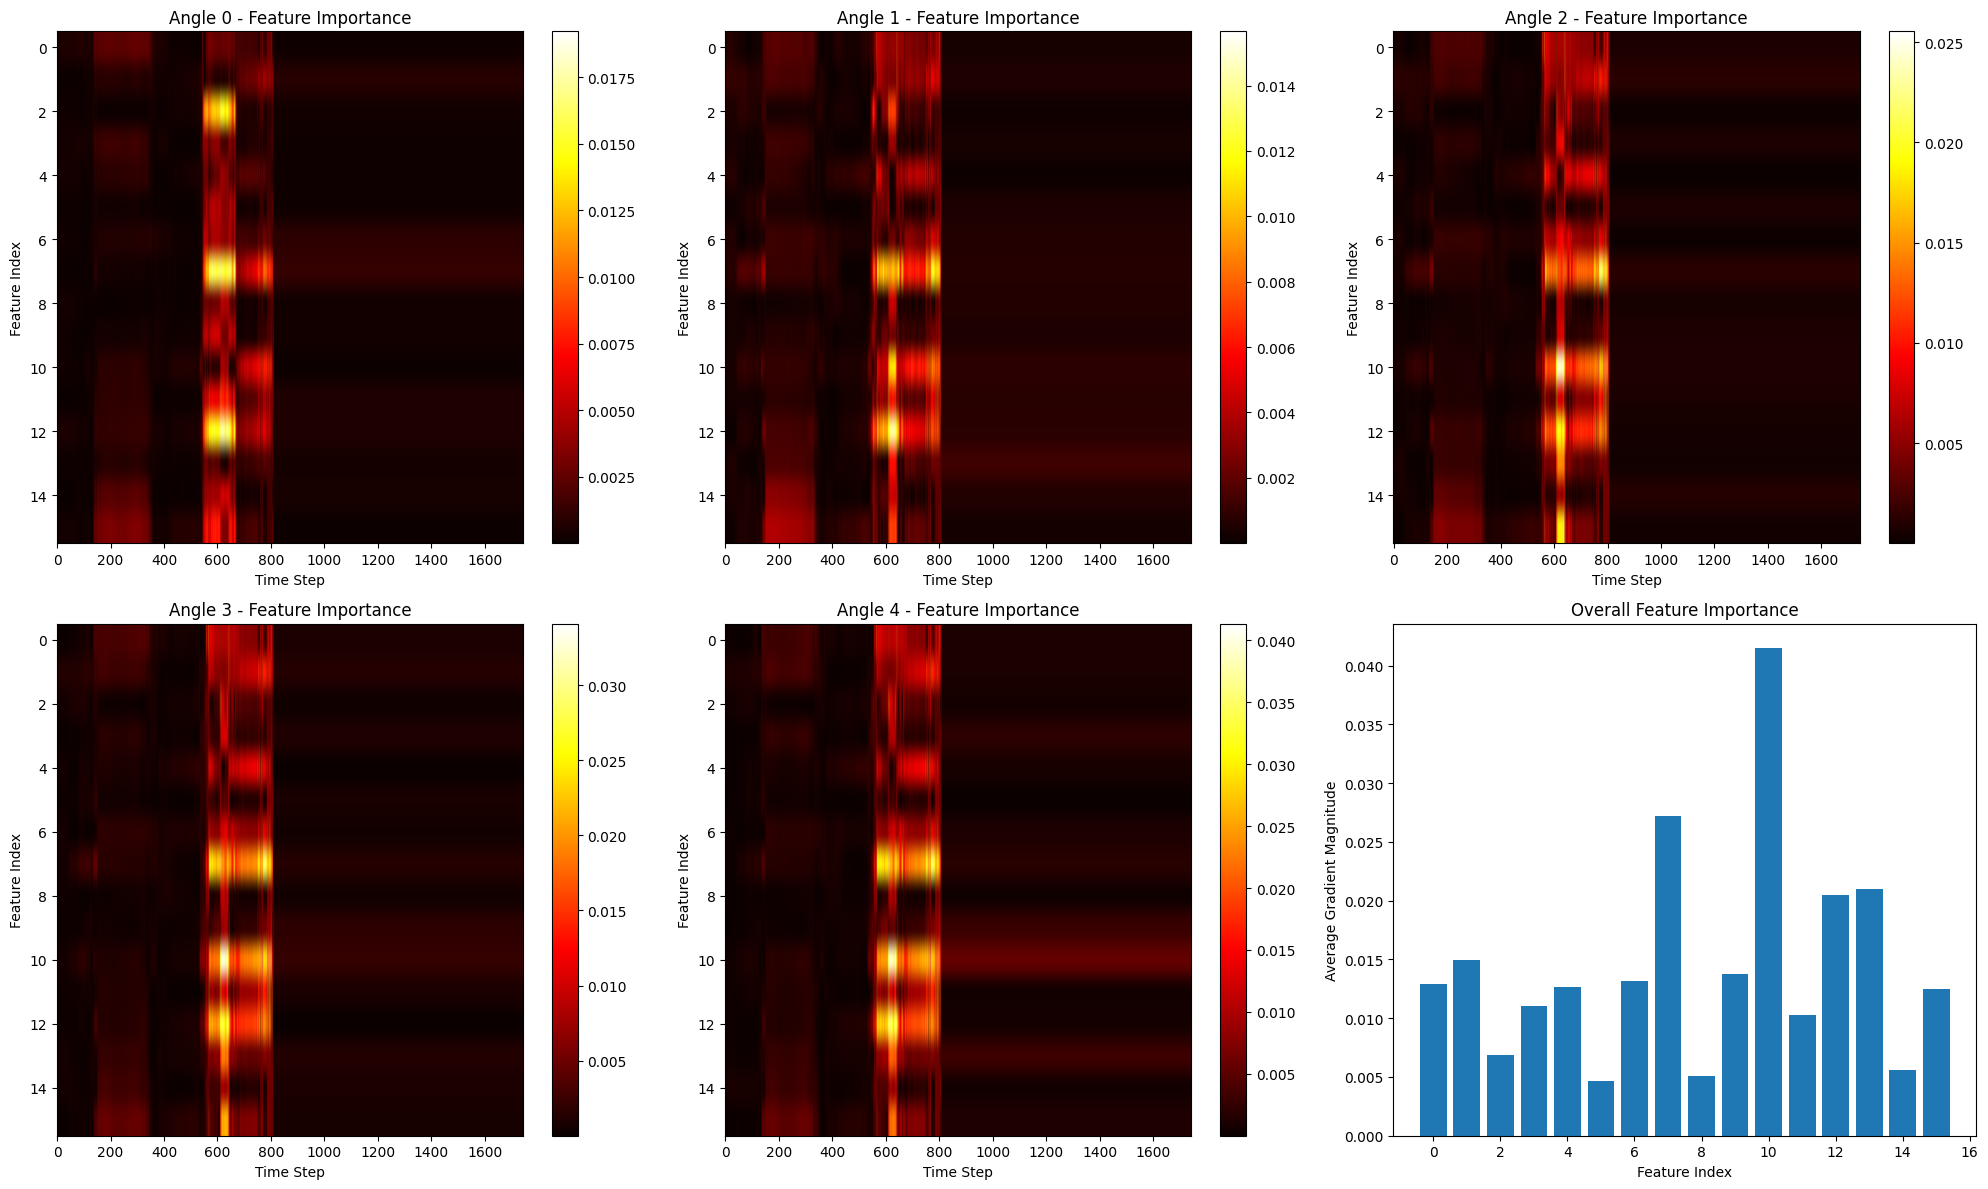

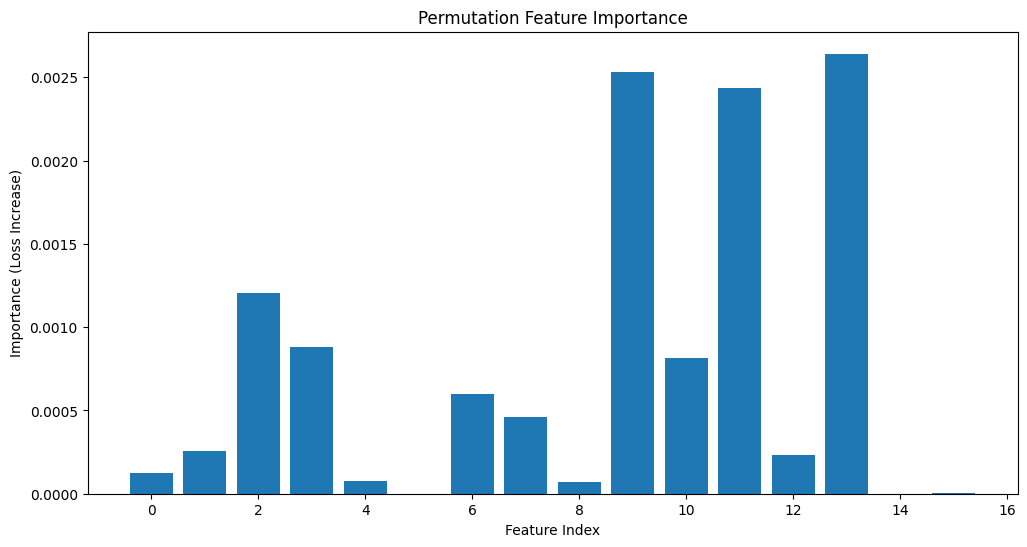

In [32]:
# After training your model
target_id = 4
experiment_ids=[4]
preds, temp_importance, perm_importance = get_experiment_analysis(
    model, X, Y, experiment_ids, target_experiment_id=target_id
)
